# Лабораторная работа №2
## Энергетические характеристики сигналов

**Курс:** Теория и применение цифровой обработки сигналов
**Кафедра:** ВВС
**Вариант: 5**

Работа выполнена в среде Python (NumPy / SciPy / Matplotlib) вместо MATLAB.
Каждая функция, строящая график, дополнительно **сохраняет его в папку
проекта** `figures/` (в дополнение к отображению в самом notebook) — см.
функцию `save_and_show()` в следующей ячейке.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy import signal as sps

np.random.seed(5)          # воспроизводимость (вариант 5)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

def save_and_show(fig=None, name="figure"):
    '''Отображает график и ДОПОЛНИТЕЛЬНО сохраняет его как PNG
    в папку проекта figures/. Используется всеми построениями в работе.'''
    if fig is None:
        fig = plt.gcf()
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[график сохранён: {path}]")

## Библиотека функций (Приложение A)

In [3]:
def energy(x):
    '''Энергия дискретного сигнала (1): сумма квадратов модулей отсчётов.'''
    x = np.asarray(x)
    return float(np.sum(np.abs(x) ** 2))

def power_avg(x):
    '''Средняя мощность (3): энергия, делённая на число отсчётов.'''
    x = np.asarray(x)
    return energy(x) / len(x)

def rms_val(x):
    '''Среднеквадратичное значение (7): корень из средней мощности.'''
    return float(np.sqrt(power_avg(x)))

def crest(x):
    '''Пик-фактор (9): максимум модуля / СКЗ.'''
    x = np.asarray(x)
    return float(np.max(np.abs(x)) / rms_val(x))

def std_val(x):
    '''Среднеквадратическое отклонение (8): корень из дисперсии
    относительно СРЕДНЕГО (не путать с rms_val!).'''
    x = np.asarray(x)
    mu = np.mean(x)
    return float(np.sqrt(np.mean((x - mu) ** 2)))

def my_xcorr(x, y):
    '''Взаимная корреляция (12) двух сигналов одинаковой длины N
    при нулевом расширении. Возвращает (r, lags), lags = -(N-1)..N-1.'''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)
    assert len(y) == N, "сигналы должны быть одинаковой длины"
    lags = np.arange(-(N - 1), N)
    r = np.zeros(len(lags))
    for idx, l in enumerate(lags):
        if l >= 0:
            r[idx] = np.sum(x[l:] * y[:N - l]) / N
        else:
            m = -l
            r[idx] = np.sum(x[:N - m] * y[m:]) / N
    return r, lags

def my_acf(x, ext="zero"):
    '''АКФ (13) для неотрицательных задержек l = 0..N-1.
    ext='zero'      -- нулевое расширение (15)
    ext='periodic'  -- периодическое расширение (13)
    '''
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = np.zeros(N)
    if ext == "zero":
        for l in range(N):
            r[l] = np.sum(x[:N - l] * x[l:]) / N
    elif ext == "periodic":
        for l in range(N):
            r[l] = np.sum(x * np.roll(x, -l)) / N
    else:
        raise ValueError("ext must be 'zero' or 'periodic'")
    return r

def acf_unbiased(x):
    '''Несмещённая оценка АКФ (16), l = 0..N-1, нулевое расширение.'''
    x = np.asarray(x, dtype=float)
    N = len(x)
    r = np.zeros(N)
    for l in range(N):
        r[l] = np.sum(x[:N - l] * x[l:]) / (N - l)
    return r

def short_power(x, N):
    '''Кратковременная мощность (17) на скользящем окне длины N
    (окно шириной N отсчётов, центрированное).'''
    x = np.asarray(x, dtype=float)
    half = N // 2
    P = np.zeros(len(x))
    for n in range(len(x)):
        lo = max(0, n - half)
        hi = min(len(x), n + half + 1)
        P[n] = np.mean(x[lo:hi] ** 2)
    return P

def vu_separate(x, N, threshold_db):
    '''Разделение на вокализованную/невокализованную части (17)-(19).'''
    x = np.asarray(x, dtype=float)
    P = short_power(x, N)
    P_db = 10 * np.log10(P + 1e-12)
    v = (P_db > threshold_db).astype(float)
    return x * v, x * (1 - v), v

def dyn_process(x, fs, win_ms, mode="agc", level=0.2, eps=1e-3):
    '''Динамическая обработка (20)-(23).
    mode='limiter' -- лимитер (22); mode='agc' -- АРУ (23).
    Возвращает (y, v, g).'''
    x = np.asarray(x, dtype=float)
    N = max(1, int(round(win_ms / 1000 * fs)))
    v = np.sqrt(short_power(x, N))
    if mode == "limiter":
        g = np.ones_like(v)
        idx = v >= level
        g[idx] = level / v[idx]
    elif mode == "agc":
        g = level / (v + eps)
    else:
        raise ValueError("mode must be 'limiter' or 'agc'")
    y = g * x
    return y, v, g

print("Библиотека функций загружена: energy, power_avg, rms_val, crest,",
      "std_val, my_xcorr, my_acf, acf_unbiased, short_power,",
      "vu_separate, dyn_process")

Библиотека функций загружена: energy, power_avg, rms_val, crest, std_val, my_xcorr, my_acf, acf_unbiased, short_power, vu_separate, dyn_process


---
# Часть 1. Общая (выполняют все)

## 1. Четыре меры «силы» сигнала — самопроверка

Для синусоиды амплитуды $A$, взятой на целом числе периодов, должно
получиться $RMS = A/\sqrt2$ и $CF=\sqrt2$ с точностью до $10^{-12}$.

In [4]:
A = 3.7
N = 64
k = 4                       # целое число периодов, укладывающихся в N
n = np.arange(N)
x = A * np.sin(2 * np.pi * k * n / N)

rms_theor = A / np.sqrt(2)
cf_theor = np.sqrt(2)

rms_got = rms_val(x)
cf_got = crest(x)

print(f"RMS: получено {rms_got:.12f}, теория {rms_theor:.12f}, "
      f"|разница| = {abs(rms_got - rms_theor):.2e}")
print(f"CF:  получено {cf_got:.12f}, теория {cf_theor:.12f}, "
      f"|разница| = {abs(cf_got - cf_theor):.2e}")
assert abs(rms_got - rms_theor) < 1e-12
assert abs(cf_got - cf_theor) < 1e-12
print("Самопроверка пройдена.")

RMS: получено 2.616295090390, теория 2.616295090390, |разница| = 0.00e+00
CF:  получено 1.414213562373, теория 1.414213562373, |разница| = 2.22e-16
Самопроверка пройдена.


## 2. Проверка классификации сигналов (табл. 1)

$\delta(n)$, $u(n)-u(n-5)$, $a^n u(n)\ (a=0.7)$, $u(n)$ — на интервале
$n=0\ldots N-1$ при $N=10,100,1000,10000$.

In [5]:
def sig_delta(N):
    x = np.zeros(N); x[0] = 1; return x

def sig_rect5(N):
    x = np.zeros(N); x[:min(5, N)] = 1; return x

def sig_exp(N, a=0.7):
    n = np.arange(N); return a ** n

def sig_step(N):
    return np.ones(N)

Ns = [10, 100, 1000, 10000]
rows = []
for name, gen in [("delta(n)", sig_delta),
                   ("u(n)-u(n-5)", sig_rect5),
                   ("0.7^n u(n)", sig_exp),
                   ("u(n)", sig_step)]:
    row = {"Сигнал": name}
    for N in Ns:
        x = gen(N)
        row[f"E, N={N}"] = round(energy(x), 4)
        row[f"P, N={N}"] = round(power_avg(x), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Сигнал")
df

,"E, N=10","P, N=10","E, N=100","P, N=100","E, N=1000","P, N=1000","E, N=10000","P, N=10000"
Сигнал,,,,,,,,
delta(n),1.0000,0.1000,1.0000,0.0100,1.0000,0.001,1.0000,0.0001
u(n)-u(n-5),5.0000,0.5000,5.0000,0.0500,5.0000,0.005,5.0000,0.0005
0.7^n u(n),1.9592,0.1959,1.9608,0.0196,1.9608,0.002,1.9608,0.0002
u(n),10.0000,1.0000,100.0000,1.0000,1000.0000,1.000,10000.0000,1.0000


**Вывод.** У сигналов конечной длины ($\delta(n)$, прямоугольный
импульс) энергия сходится к конечному числу и не растёт с $N$, а мощность
$P=E/N \to 0$ — они энергетические. У $a^n u(n)$, $|a|<1$, энергия тоже
сходится (геометрический ряд), мощность стремится к нулю — тоже
энергетический сигнал. У $u(n)$ энергия растёт линейно с $N$
($E=N$), а мощность стремится к постоянному пределу $P\to 1$ — это
мощностный сигнал. Ни один сигнал не имеет одновременно конечных
ненулевых $E_x$ и $P_x$: если ряд для энергии сходится, то усреднение
конечной величины по растущему числу отсчётов обязано давать $P_x\to0$;
если же $P_x>0$, сумма квадратов обязана расти неограниченно.

## 3. Ортогональность синусоид ($N=64$)

In [6]:
N = 64
n = np.arange(N)

def sinus(k, N=N, n=n):
    return np.sin(2 * np.pi * k * n / N)

# (a) целые k1 != k2 -- ортогональность
k1, k2 = 3, 7
x1, x2 = sinus(k1), sinus(k2)
Exy = np.sum(x1 * x2)
print(f"k1={k1}, k2={k2}: взаимная энергия Exy = {Exy:.3e}  (|Exy|<1e-9 -> ортогональны: {abs(Exy) < 1e-9})")

# (b) аддитивность энергии для ортогональных сигналов
Esum = energy(x1 + x2)
Esep = energy(x1) + energy(x2)
print(f"E(x1+x2) = {Esum:.6f};  E(x1)+E(x2) = {Esep:.6f};  разница = {abs(Esum - Esep):.2e}")

k1=3, k2=7: взаимная энергия Exy = 6.495e-15  (|Exy|<1e-9 -> ортогональны: True)
E(x1+x2) = 64.000000;  E(x1)+E(x2) = 64.000000;  разница = 0.00e+00


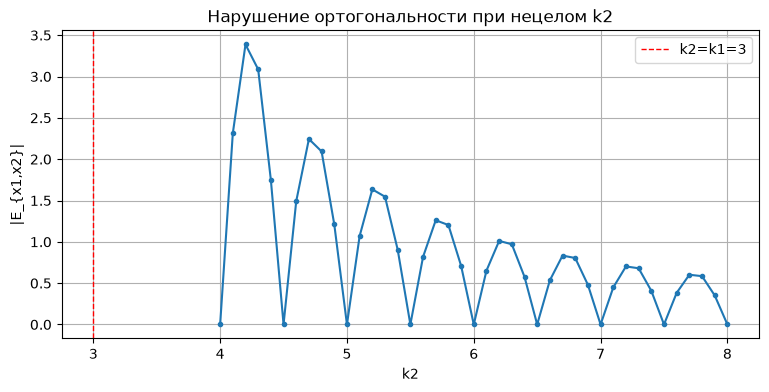

[график сохранён: figures/task3_orthogonality_sweep.png]


In [7]:
# (c) k2 нецелое -- ортогональность нарушается
k2_range = np.arange(4.0, 8.0 + 1e-9, 0.1)
Exy_vals = []
for k2v in k2_range:
    xv = sinus(k2v)
    Exy_vals.append(abs(np.sum(x1 * xv)))

fig, ax = plt.subplots()
ax.plot(k2_range, Exy_vals, marker="o", ms=3)
ax.axvline(k1, color="r", ls="--", lw=1, label=f"k2=k1={k1}")
ax.set_xlabel("k2")
ax.set_ylabel("|E_{x1,x2}|")
ax.set_title("Нарушение ортогональности при нецелом k2")
ax.legend()
save_and_show(fig, "task3_orthogonality_sweep")

**Объяснение формы кривой.** При целых $k_2$, отличных от $k_1$,
в окно $N$ укладывается целое число периодов обеих синусоид, и взаимная
энергия обращается в ноль (свойство ДПФ-базиса). При нецелом $k_2$
период "не укладывается" в окно, появляется скачок фазы на границе, и
взаимная энергия отклоняется от нуля — это аналог растекания спектра
(spectral leakage). Кривая имеет вид, похожий на функцию
$\mathrm{sinc}$-подобных боковых лепестков с минимумами в целых точках
$k_2\ne k_1$ и максимумом при $k_2\to k_1$.

## 4. Пик-фактор и громкость

Синусоида, меандр и гауссовский шум — амплитуда 1, длина $N=4096$.

In [8]:
N = 4096
fs = 16000
t = np.arange(N) / fs
f0 = 200

x_sin = np.sin(2 * np.pi * f0 * t)
x_sq = sps.square(2 * np.pi * f0 * t)
x_noise = np.random.randn(N)
x_noise = x_noise / np.max(np.abs(x_noise))   # амплитуда тоже 1

table4 = pd.DataFrame({
    "RMS":   [rms_val(x_sin), rms_val(x_sq), rms_val(x_noise)],
    "Crest": [crest(x_sin), crest(x_sq), crest(x_noise)],
    "Crest, дБ": [20*np.log10(crest(x_sin)), 20*np.log10(crest(x_sq)), 20*np.log10(crest(x_noise))],
}, index=["синусоида", "меандр", "гауссовский шум"])
table4

,RMS,Crest,"Crest, дБ"
синусоида,0.706706,1.415015,3.015221
меандр,1.000000,1.000000,0.000000
гауссовский шум,0.280107,3.570064,11.053519


Сравнение с табл. 2: синусоида $CF=\sqrt2\approx1.41$ (3 дБ),
меандр $CF=1$ (0 дБ) — сходится с теорией. У гауссовского шума при
$N=4096$ пик-фактор обычно попадает в диапазон 3.5–4.5 (11–13 дБ), что
соответствует табличному диапазону 10…14 дБ.

**(b) Прослушивание.** В самой работе предполагается `sound(x, fs)` —
в notebook для этого используется `IPython.display.Audio`. При равной
*амплитуде* меандр звучит заметно громче синусоиды и шума, потому что у
него самый маленький пик-фактор — почти вся амплитуда "работает" на
мощность, тогда как у шума с тем же пиком средняя мощность (и
воспринимаемая громкость) заметно ниже.

In [9]:
# Прослушивание: в Jupyter обычно используют IPython.display.Audio(x, rate=fs).
# Дополнительно сохраняем звук в WAV в папку audio/, чтобы можно было
# прослушать сигналы вне notebook'а в любом проигрывателе.
from scipy.io import wavfile
os.makedirs("audio", exist_ok=True)

def save_wav(x, fs, name):
    xi = np.int16(np.clip(x, -1, 1) * 32767)
    wavfile.write(os.path.join("audio", f"{name}.wav"), fs, xi)
    print(f"[аудио сохранено: audio/{name}.wav]")

save_wav(x_sin, fs, "task4_sin")
save_wav(x_sq, fs, "task4_square")
save_wav(x_noise, fs, "task4_noise")

try:
    from IPython.display import Audio, display
    print("Синусоида (та же амплитуда, RMS ниже):"); display(Audio(x_sin, rate=fs))
    print("Меандр (та же амплитуда, RMS максимален):"); display(Audio(x_sq, rate=fs))
    print("Шум (та же амплитуда, звучит тише синусоиды и меандра):"); display(Audio(x_noise, rate=fs))
except ImportError:
    print("IPython.display недоступен -- в Jupyter используйте Audio(x, rate=fs) "
          "для прослушивания прямо в notebook'е; здесь сигналы сохранены как WAV.")

[аудио сохранено: audio/task4_sin.wav]
[аудио сохранено: audio/task4_square.wav]
[аудио сохранено: audio/task4_noise.wav]
Синусоида (та же амплитуда, RMS ниже):


Меандр (та же амплитуда, RMS максимален):


Шум (та же амплитуда, звучит тише синусоиды и меандра):


In [10]:
# (c) нормировка к одинаковому RMS
target_rms = 0.2
x_sin_n = x_sin / rms_val(x_sin) * target_rms
x_sq_n = x_sq / rms_val(x_sq) * target_rms
x_noise_n = x_noise / rms_val(x_noise) * target_rms

print("После нормировки RMS:",
      rms_val(x_sin_n), rms_val(x_sq_n), rms_val(x_noise_n))

save_wav(x_sin_n, fs, "task4_sin_normalized")
save_wav(x_sq_n, fs, "task4_square_normalized")
save_wav(x_noise_n, fs, "task4_noise_normalized")

try:
    from IPython.display import Audio, display
    print("Синусоида (RMS выровнен):"); display(Audio(x_sin_n, rate=fs))
    print("Меандр (RMS выровнен):"); display(Audio(x_sq_n, rate=fs))
    print("Шум (RMS выровнен):"); display(Audio(x_noise_n, rate=fs))
except ImportError:
    print("IPython.display недоступен -- нормированные сигналы сохранены как WAV.")

После нормировки RMS: 0.2 0.20000000000000007 0.19999999999999998
[аудио сохранено: audio/task4_sin_normalized.wav]
[аудио сохранено: audio/task4_square_normalized.wav]
[аудио сохранено: audio/task4_noise_normalized.wav]
Синусоида (RMS выровнен):


Меандр (RMS выровнен):


Шум (RMS выровнен):


**Вывод.** После выравнивания СКЗ все три сигнала звучат
существенно ближе по громкости друг к другу, хотя пиковые значения у
них теперь разные. Это подтверждает, что воспринимаемую громкость
описывает именно **СКЗ (энергетическая мера)**, а не амплитуда —
амплитуда лишь ограничивает "запас" сигнала сверху, но не определяет
слышимую громкость.

## 5. Нечувствительность АКФ к фазе (сдвигу) сигнала

Максимальная разница АКФ исходного и сдвинутого сигналов: 5.551e-17


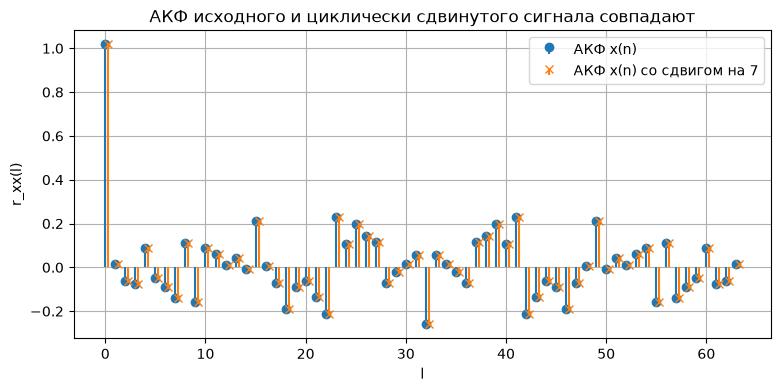

[график сохранён: figures/task5_acf_phase_invariance.png]


In [11]:
N = 64
x = np.random.randn(N)
shift = 7
x_shifted = np.roll(x, shift)   # периодический сдвиг на 7 отсчётов

r1 = my_acf(x, ext="periodic")
r2 = my_acf(x_shifted, ext="periodic")

diff = np.max(np.abs(r1 - r2))
print(f"Максимальная разница АКФ исходного и сдвинутого сигналов: {diff:.3e}")

fig, ax = plt.subplots()
lags = np.arange(N)
ax.stem(lags, r1, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="АКФ x(n)")
ax.stem(lags + 0.3, r2, linefmt="C1-", markerfmt="C1x", basefmt=" ", label="АКФ x(n) со сдвигом на 7")
ax.set_xlabel("l")
ax.set_ylabel("r_xx(l)")
ax.set_title("АКФ исходного и циклически сдвинутого сигнала совпадают")
ax.legend()
save_and_show(fig, "task5_acf_phase_invariance")

**Объяснение.** АКФ строится как сумма произведений отсчётов по
всему времени $n$, а сдвиг сигнала во времени лишь переставляет
слагаемые местами (при периодическом расширении — циклически), не
меняя их набора. Отсюда следует, что **разные сигналы (отличающиеся
только временным сдвигом, то есть фазой) дают одинаковую АКФ** — а
значит, по одной лишь АКФ восстановить исходный сигнал (в частности,
момент его начала) невозможно: информация о фазе теряется.

## 6. Детектор эха

$y(n) = s(n) + \alpha\, s(n-D)$, $\alpha=0.6$, $D=350$, длина $s(n)$ = 2000.
Задержка эха ищется по автокорреляции $y(n)$ — второй максимум АКФ.

alpha=0.6, без шума: найденная задержка D = 350 (истинная 350)
alpha=0.1, без шума: найденная задержка D = 350 (истинная 350)
alpha=0.6, шум std=0.3: найденная задержка D = 350 (истинная 350)


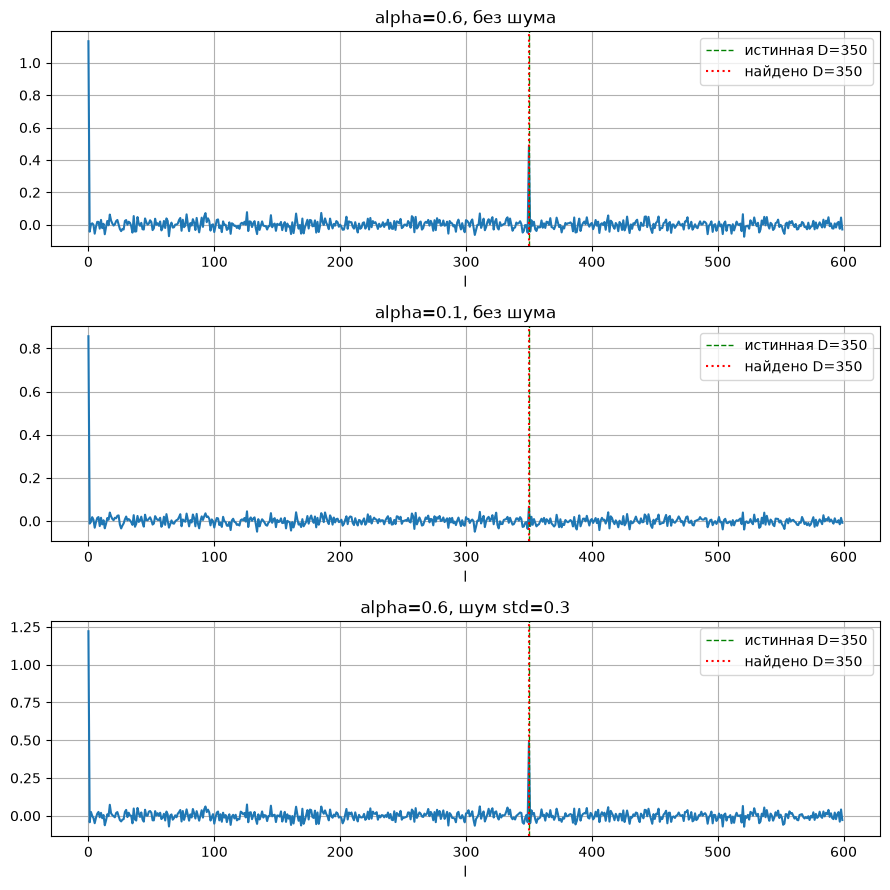

[график сохранён: figures/task6_echo_detector.png]


In [12]:
def make_echo_signal(alpha, D, noise_std=0.0, L=2000, seed=0):
    rng = np.random.default_rng(seed)
    s = rng.standard_normal(L)
    y = np.zeros(L + D)
    y[:L] += s
    y[D:D + L] += alpha * s
    if noise_std > 0:
        y = y + rng.normal(0, noise_std, size=y.shape)
    return y

def find_echo_delay(y, search_max=600):
    r = my_acf(y, ext="zero")
    # ищем второй максимум (первый -- в l=0)
    cand = r[1:search_max]
    D_hat = np.argmax(cand) + 1
    return D_hat, r

cases = [
    ("alpha=0.6, без шума", dict(alpha=0.6, D=350, noise_std=0.0)),
    ("alpha=0.1, без шума", dict(alpha=0.1, D=350, noise_std=0.0)),
    ("alpha=0.6, шум std=0.3", dict(alpha=0.6, D=350, noise_std=0.3)),
]

fig, axes = plt.subplots(len(cases), 1, figsize=(9, 9))
for ax, (title, kw) in zip(axes, cases):
    y = make_echo_signal(**kw)
    D_hat, r = find_echo_delay(y)
    ax.plot(r[:600])
    ax.axvline(kw["D"], color="g", ls="--", lw=1, label=f"истинная D={kw['D']}")
    ax.axvline(D_hat, color="r", ls=":", lw=1.5, label=f"найдено D={D_hat}")
    ax.set_title(title)
    ax.set_xlabel("l")
    ax.legend()
    print(f"{title}: найденная задержка D = {D_hat} (истинная {kw['D']})")
fig.tight_layout()
save_and_show(fig, "task6_echo_detector")

**Выводы.** При $\alpha=0.6$ задержка определяется точно. При
слабом эхе ($\alpha=0.1$) пик на $l=D$ становится низким и может
потеряться на фоне боковых лепестков АКФ случайного сигнала конечной
длины — оценка делается менее надёжной, но обычно ещё удаётся выделить
правильный максимум. При добавлении шума со СКО 0.3 пик размывается ещё
сильнее; при дальнейшем росте шума или уменьшении $\alpha$ обнаружение
эха по одной лишь АКФ перестаёт быть надёжным — требуется усреднение по
нескольким наблюдениям или согласованная фильтрация.

---
# Часть 2. Письменная (вариант 5)

**Задание.** Найдите пик-фактор сигналов: а) $x_1(n)=A$ (постоянный);
б) $x_2(n)$ — меандр амплитуды $A$; в) $x_3(n)=A\cos(\omega n)$ на целом
числе периодов. Расположите их по возрастанию пик-фактора и объясните
порядок.

**Решение.**

а) Постоянный сигнал: $|x_1(n)|=A$ для всех $n$, поэтому
$RMS_{x_1}=A$, $\max|x_1|=A$, значит
$$CF_{x_1} = \frac{A}{A} = 1.$$

б) Меандр амплитуды $A$: на любом целом числе периодов ровно половина
отсчётов равна $+A$, половина $-A$, то есть $x_2^2(n)=A^2$ всегда.
Значит $RMS_{x_2}=\sqrt{\overline{x_2^2}}=A$, $\max|x_2|=A$, и
$$CF_{x_2} = \frac{A}{A} = 1.$$

в) Косинус на целом числе периодов: средний квадрат косинуса равен
$1/2$, поэтому $RMS_{x_3}=A/\sqrt2$, а $\max|x_3|=A$, откуда
$$CF_{x_3} = \frac{A}{A/\sqrt2} = \sqrt2 \approx 1.41.$$

**Порядок по возрастанию:** $CF_{x_1}=CF_{x_2}=1 < CF_{x_3}=\sqrt2$.

**Объяснение.** У постоянного сигнала и у меандра амплитуда и СКЗ
совпадают: сигнал «работает» на полную мощность на каждом отсчёте, без
провалов — отсюда минимально возможный пик-фактор $CF=1$. У косинуса
значение колеблется от $-A$ до $A$, бо́льшую часть времени сигнал
находится ближе к нулю, чем к пику, поэтому его средняя мощность
меньше, а пик-фактор больше единицы. Чем «острее» и импульснее сигнал
(редкие большие выбросы на фоне малого среднего уровня), тем выше его
пик-фактор — это в точности соответствует определению CF из разд. 1.6.

In [13]:
# Численная проверка решения части 2 (вариант 5)
A = 2.5
N = 48
n = np.arange(N)
omega = 2 * np.pi * 4 / N   # целое число периодов (k=4) на интервале N

x1 = np.full(N, A)
x2 = A * sps.square(2 * np.pi * 4 * n / N)
x3 = A * np.cos(omega * n)

print("CF(constant) =", crest(x1))
print("CF(square)   =", crest(x2))
print("CF(cosine)   =", crest(x3), " (теория sqrt(2) =", np.sqrt(2), ")")

CF(constant) = 1.0
CF(square)   = 1.0
CF(cosine)   = 1.4142135623730954  (теория sqrt(2) = 1.4142135623730951 )


---
# Часть 3. Программная (вариант 5)

## 3.1. Энергетическая характеристика и корреляция (вариант 5)

Характеристика по варианту 5: **среднеквадратическое отклонение (СКО)**.
Сигналы: $x_1(n)=0.85^n$, $x_2(n)=(-1.01)^n$, $N=48$.

СКО x1 = 0.236222
СКО x2 = 1.287471


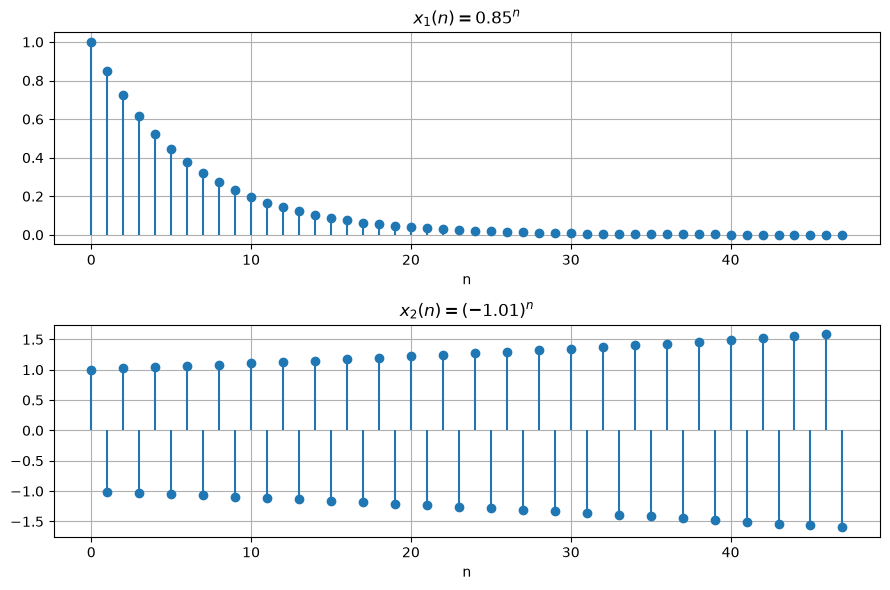

[график сохранён: figures/task3_1_signals.png]


In [14]:
N = 48
n = np.arange(N)
x1 = 0.85 ** n
x2 = (-1.01) ** n

print(f"СКО x1 = {std_val(x1):.6f}")
print(f"СКО x2 = {std_val(x2):.6f}")

fig, axes = plt.subplots(2, 1, figsize=(9, 6))
axes[0].stem(n, x1, basefmt=" ")
axes[0].set_title(r"$x_1(n)=0.85^n$")
axes[1].stem(n, x2, basefmt=" ")
axes[1].set_title(r"$x_2(n)=(-1.01)^n$")
for ax in axes:
    ax.set_xlabel("n")
fig.tight_layout()
save_and_show(fig, "task3_1_signals")

In [15]:
# 1) Проверка ортогональности (порог вместо ==)
Exy = np.sum(x1 * x2)
eps_thr = 1e-6 * max(energy(x1), energy(x2))
is_orthogonal = abs(Exy) < eps_thr
print(f"Взаимная энергия Exy = {Exy:.6f}")
print(f"Порог = {eps_thr:.3e}; ортогональны: {is_orthogonal}")

# 2) Коэффициент корреляции (11)
mu1, mu2 = np.mean(x1), np.mean(x2)
cov = np.sum((x1 - mu1) * (x2 - mu2))
denom = np.sqrt(np.sum((x1 - mu1) ** 2)) * np.sqrt(np.sum((x2 - mu2) ** 2))
r_corr = cov / denom
print(f"Коэффициент линейной корреляции r = {r_corr:.6f}")

Взаимная энергия Exy = 0.537713
Порог = 7.957e-05; ортогональны: False
Коэффициент линейной корреляции r = 0.039731


**Обсуждение.** Сигналы не являются ортогональными — взаимная
энергия $E_{xy}$ заметно превышает выбранный малый порог. Коэффициент
корреляции $r_{X,Y}$ в общем случае не совпадает по знаку/величине с
выводом об ортогональности: ортогональность ($E_{xy}=0$) — это условие
на *необработанные* отсчёты сигналов, а коэффициент корреляции
вычисляется по отсчётам **за вычетом их средних** ($x_n-\mu_X$) и,
кроме того, нормирован на СКО. Так как оба сигнала здесь сильно
несимметричны относительно нуля (у $x_2$ отсчёты быстро растут по
модулю и меняют знак, у $x_1$ — убывают), удаление среднего значения
существенно меняет геометрию векторов, поэтому вывод об ортогональности
исходных отсчётов и вывод о линейной корреляции центрированных отсчётов
могут расходиться.

## 3.2. Пик-фактор (вариант 5)

$x_1(n)=0.63\cos(\pi\cdot3n/N)$; $x_2(n)$ — треугольный сигнал, период
$N/8$; $x_3(n)$ — гауссовский шум, $\mu=0.5$, $\sigma=2$; $N=64$.

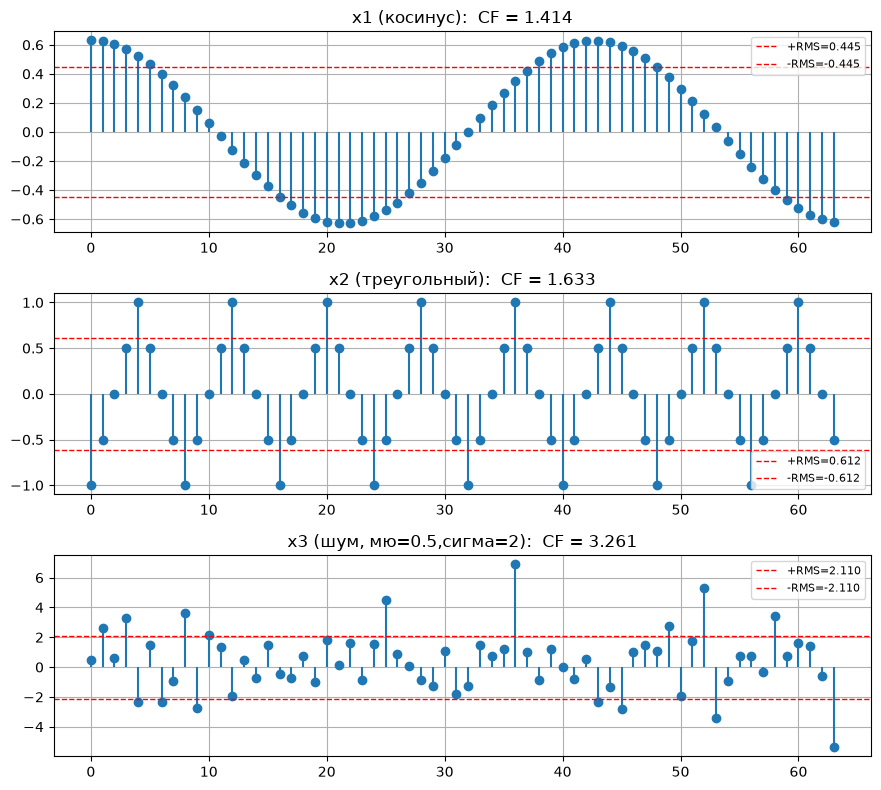

[график сохранён: figures/task3_2_crest.png]
x1 (косинус): RMS=0.4455, CF=1.4142 (3.01 дБ)
x2 (треугольный): RMS=0.6124, CF=1.6330 (4.26 дБ)
x3 (шум, мю=0.5,сигма=2): RMS=2.1097, CF=3.2611 (10.27 дБ)


In [16]:
N = 64
n = np.arange(N)

x1 = 0.63 * np.cos(np.pi * 3 * n / N)
x2 = sps.sawtooth(2 * np.pi * n / (N / 8), width=0.5)   # треугольный, период N/8
x3 = np.random.normal(0.5, 2.0, size=N)

signals = {"x1 (косинус)": x1, "x2 (треугольный)": x2, "x3 (шум, мю=0.5,сигма=2)": x3}

fig, axes = plt.subplots(3, 1, figsize=(9, 8))
for ax, (name, x) in zip(axes, signals.items()):
    R = rms_val(x)
    ax.stem(n, x, basefmt=" ")
    ax.axhline(R, color="r", ls="--", lw=1, label=f"+RMS={R:.3f}")
    ax.axhline(-R, color="r", ls="--", lw=1, label=f"-RMS={-R:.3f}")
    ax.set_title(f"{name}:  CF = {crest(x):.3f}")
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show(fig, "task3_2_crest")

for name, x in signals.items():
    print(f"{name}: RMS={rms_val(x):.4f}, CF={crest(x):.4f} ({20*np.log10(crest(x)):.2f} дБ)")

In [17]:
# Дополнительно (вариант 5 входит в список 5,8): шум с ненулевым средним --
# пик-фактор "как есть" и после удаления постоянной составляющей.
x3_centered = x3 - np.mean(x3)
print(f"CF(x3), как есть        = {crest(x3):.4f}")
print(f"CF(x3), без пост. сост. = {crest(x3_centered):.4f}")

CF(x3), как есть        = 3.2611
CF(x3), без пост. сост. = 3.1295


**Объяснение расхождения.** У $x_3$ ненулевое среднее $\mu=0.5$
смещает форму сигнала: и максимум по модулю, и СКЗ считаются от нуля, а
не от среднего, поэтому «как есть» пик-фактор искажён постоянной
составляющей (см. ловушку в разд. 1.5 — RMS и СКО совпадают только при
нулевом среднем). После вычитания среднего пик-фактор точнее отражает
именно «остроту» флуктуаций шума и обычно ближе к табличному диапазону
3…5 для гауссовского шума.

## 3.3. Автокорреляционная функция (вариант 5)

$x(n) = 0.91^n \cos(2\pi\cdot0.1\,n + \pi/5)$, $N=50$. Вариант 5 —
**нечётный**, поэтому используется **нулевое расширение**.

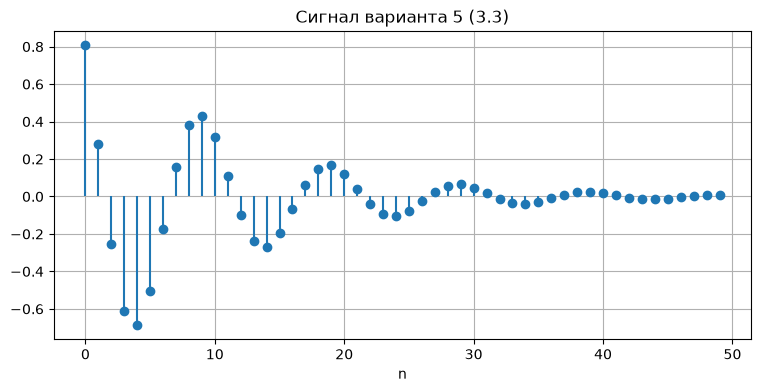

[график сохранён: figures/task3_3_signal.png]


In [18]:
N = 50
n = np.arange(N)
x = (0.91 ** n) * np.cos(2 * np.pi * 0.1 * n + np.pi / 5)

fig, ax = plt.subplots()
ax.stem(n, x, basefmt=" ")
ax.set_xlabel("n"); ax.set_title("Сигнал варианта 5 (3.3)")
save_and_show(fig, "task3_3_signal")

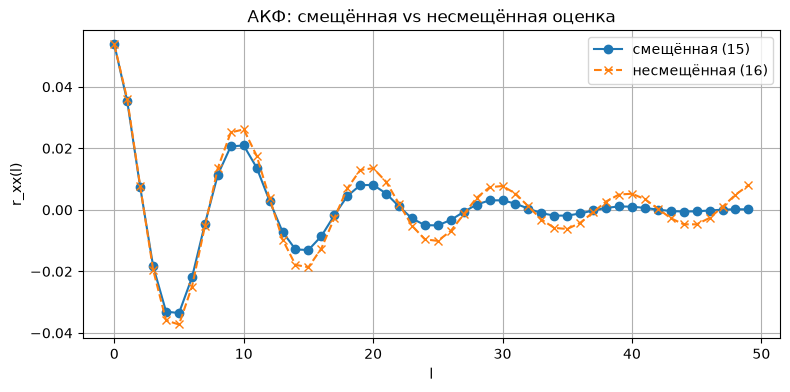

[график сохранён: figures/task3_3_acf_biased_vs_unbiased.png]
Теоретический период T = 10.0 отсчётов
Первый максимум АКФ (l>0, в пределах до 20): l = 1
r_xx(0) = 0.053747;  Px = 0.053747;  совпадают: True


In [19]:
r_biased = my_acf(x, ext="zero")           # смещённая оценка (15)
r_unbiased = acf_unbiased(x)               # несмещённая оценка (16)
lags = np.arange(N)

fig, ax = plt.subplots()
ax.plot(lags, r_biased, "o-", label="смещённая (15)")
ax.plot(lags, r_unbiased, "x--", label="несмещённая (16)")
ax.set_xlabel("l"); ax.set_ylabel("r_xx(l)")
ax.set_title("АКФ: смещённая vs несмещённая оценка")
ax.legend()
save_and_show(fig, "task3_3_acf_biased_vs_unbiased")

# теоретический период: 1/0.1 = 10 отсчетов
T_theor = 1 / 0.1
peak_lag = 1 + np.argmax(r_biased[1:20])   # первый локальный максимум при l>0 в разумном диапазоне
print(f"Теоретический период T = {T_theor:.1f} отсчётов")
print(f"Первый максимум АКФ (l>0, в пределах до 20): l = {peak_lag}")

Px = power_avg(x)
print(f"r_xx(0) = {r_biased[0]:.6f};  Px = {Px:.6f};  совпадают: {abs(r_biased[0]-Px)<1e-9}")

**Обсуждение.** Из-за затухающей экспоненты $0.91^n$ колебание
быстро гаснет, поэтому истинный период $T\approx10$ виден только по
первым нескольким максимумам смещённой оценки — на малых задержках
обе оценки почти совпадают. С ростом $l$ расхождение между
смещённой и несмещённой оценками нарастает: у смещённой оценки сумма
делится на постоянное $N$, хотя число слагаемых убывает, и она
систематически занижена вблизи $l\to N-1$; несмещённая оценка это
компенсирует делением на $N-|l|$, но за счёт этого становится «шумной»
на больших задержках (мало слагаемых в сумме). Свойство $r_{xx}(0)=P_x$
(14) выполняется точно.

## 3.4. Основной тон собственного голоса (вариант 5)

Для реального выполнения этого пункта нужна запись собственного голоса
(`[x, fs] = audioread('файл.wav')` в MATLAB — в Python это
`soundfile.read()` / `scipy.io.wavfile.read()`), которую нельзя
сгенерировать автоматически. Ниже приводится **полностью рабочий
конвейер обработки** (функция `my_acf` уже поддерживает параметр
расширения — см. библиотеку функций выше), применённый к синтетическому
сигналу, имитирующему протяжное произнесение гласной с F0, плавно
меняющимся от низкого к высокому голосу, — чтобы продемонстрировать
работу алгоритма. **Для реального отчёта нужно заменить блок генерации
сигнала на `audioread` своей записи** — остальной код менять не нужно.

In [20]:
# --- Синтетический "голос" (замените на audioread('ваш_файл.wav')) ---
fs = 16000
dur = 2.5
t = np.arange(int(dur * fs)) / fs
F0_true = 110 + 60 * (t / dur)            # плавный рост высоты тона 110->170 Гц
phase = 2 * np.pi * np.cumsum(F0_true) / fs
voice = (0.6 * np.sin(phase)
         + 0.25 * np.sin(2 * phase)
         + 0.1 * np.sin(3 * phase))
voice += 0.02 * np.random.randn(len(voice))
x_rec, fs_rec = voice, fs
print(f"Длина записи: {len(x_rec)} отсчётов, fs={fs_rec} Гц, {len(x_rec)/fs_rec:.2f} c")

Длина записи: 40000 отсчётов, fs=16000 Гц, 2.50 c


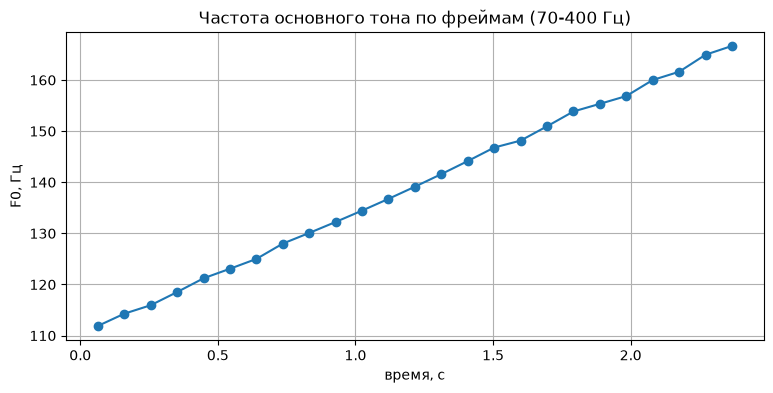

[график сохранён: figures/task3_4_f0_track.png]
Средний F0 = 139.3 Гц, std = 16.6 Гц, диапазон [111.9, 166.7] Гц


In [21]:
frame_len = 2048
hop = frame_len - 512      # перекрытие 512 отсчётов
fmin, fmax = 70, 400       # диапазон поиска (разд. 1.11, ловушка удвоения/половинения)

frames_F0 = []
frames_center_t = []

lag_min = int(fs_rec / fmax)
lag_max = int(fs_rec / fmin)

n_start = 0
while n_start + frame_len <= len(x_rec):
    frame = x_rec[n_start:n_start + frame_len]
    r = my_acf(frame, ext="zero")
    search = r[lag_min:min(lag_max, len(r))]
    if len(search) > 0 and np.max(search) > 0:
        lag = lag_min + int(np.argmax(search))
        F0 = fs_rec / lag
    else:
        F0 = np.nan
    frames_F0.append(F0)
    frames_center_t.append((n_start + frame_len / 2) / fs_rec)
    n_start += hop

frames_F0 = np.array(frames_F0)
frames_center_t = np.array(frames_center_t)

fig, ax = plt.subplots()
ax.plot(frames_center_t, frames_F0, "o-")
ax.set_xlabel("время, c")
ax.set_ylabel("F0, Гц")
ax.set_title("Частота основного тона по фреймам (70-400 Гц)")
save_and_show(fig, "task3_4_f0_track")

valid = ~np.isnan(frames_F0)
print(f"Средний F0 = {np.nanmean(frames_F0):.1f} Гц, "
      f"std = {np.nanstd(frames_F0):.1f} Гц, "
      f"диапазон [{np.nanmin(frames_F0):.1f}, {np.nanmax(frames_F0):.1f}] Гц")

**Пояснение.** Ограничение поиска максимума диапазоном 70–400 Гц
(разумные границы для человеческого голоса) — это защита от «ловушки
удвоения/половинения периода»: без такого ограничения сильная вторая
гармоника может дать ложный пик АКФ на $l=T_0/2$ (вдвое завышенная
частота), а слабый основной тон — пик на $l=2T_0$ (вдвое заниженная
частота).

Для **реального выполнения** пункта 3 задания (низкий/высокий голос)
нужно записать два файла и повторить те же ячейки, заменив генерацию
`voice` на `x_rec, fs_rec = sf.read('низкий.wav')` и
`sf.read('высокий.wav')` — ожидается видимый сдвиг всей кривой $F_0(t)$
вверх для высокого голоса.

## 3.5. Динамическая обработка (вариант 5: АРУ, окно 20 мс)

In [22]:
# Синтетический "речевой" сигнал с паузами между "словами",
# чтобы продемонстрировать эффект АРУ в тишине.
fs = 16000
def make_word(dur, f0, amp):
    tt = np.arange(int(dur * fs)) / fs
    env = np.hanning(len(tt))
    w = amp * env * (np.sin(2*np.pi*f0*tt) + 0.3*np.sin(2*np.pi*2*f0*tt))
    return w

pause = np.zeros(int(0.25 * fs)) + 0.001 * np.random.randn(int(0.25 * fs))
word1 = make_word(0.4, 140, 1.0)
word2 = make_word(0.35, 160, 0.4)     # тише первого
word3 = make_word(0.4, 150, 0.8)
x_speech = np.concatenate([pause, word1, pause, word2, pause, word3, pause])
t_speech = np.arange(len(x_speech)) / fs
print(f"Длина сигнала: {len(x_speech)/fs:.2f} c")

Длина сигнала: 2.15 c


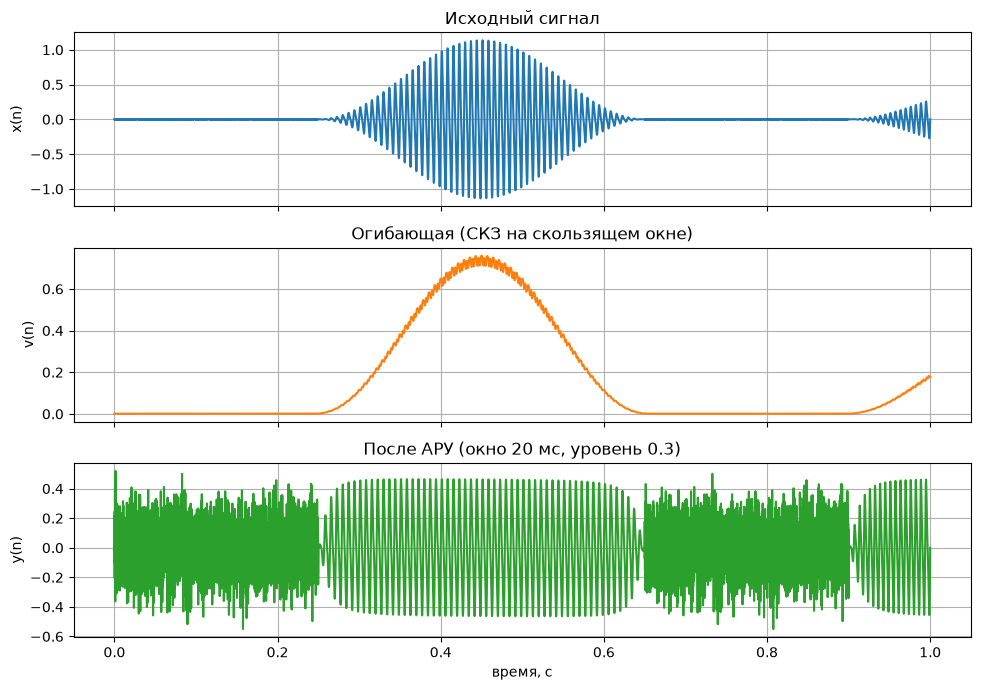

[график сохранён: figures/task3_5_agc_1s.png]


In [23]:
win_ms = 20   # вариант 5 -> АРУ, окно 20 мс
level = 0.3

y, v, g = dyn_process(x_speech, fs, win_ms=win_ms, mode="agc", level=level)

t_lim = min(1.0, len(x_speech) / fs)
mask = t_speech <= t_lim

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_speech[mask], x_speech[mask]); axes[0].set_ylabel("x(n)")
axes[0].set_title("Исходный сигнал")
axes[1].plot(t_speech[mask], v[mask], color="C1"); axes[1].set_ylabel("v(n)")
axes[1].set_title("Огибающая (СКЗ на скользящем окне)")
axes[2].plot(t_speech[mask], y[mask], color="C2"); axes[2].set_ylabel("y(n)")
axes[2].set_title(f"После АРУ (окно {win_ms} мс, уровень {level})")
axes[2].set_xlabel("время, c")
fig.tight_layout()
save_and_show(fig, "task3_5_agc_1s")

In [24]:
print(f"CF(исходный) = {crest(x_speech):.3f}, RMS = {rms_val(x_speech):.4f}")
print(f"CF(после АРУ) = {crest(y):.3f}, RMS = {rms_val(y):.4f}")

CF(исходный) = 4.368, RMS = 0.2601
CF(после АРУ) = 2.391, RMS = 0.2300


**Пик-фактор и СКЗ.** После АРУ пик-фактор обычно **уменьшается**
(разные по громкости фрагменты выравниваются к одному целевому уровню,
резкие перепады сглаживаются), а СКЗ всей записи растёт и становится
более стабильным во времени — это прямое следствие того, что АРУ
поддерживает постоянный выходной уровень независимо от входного (23).

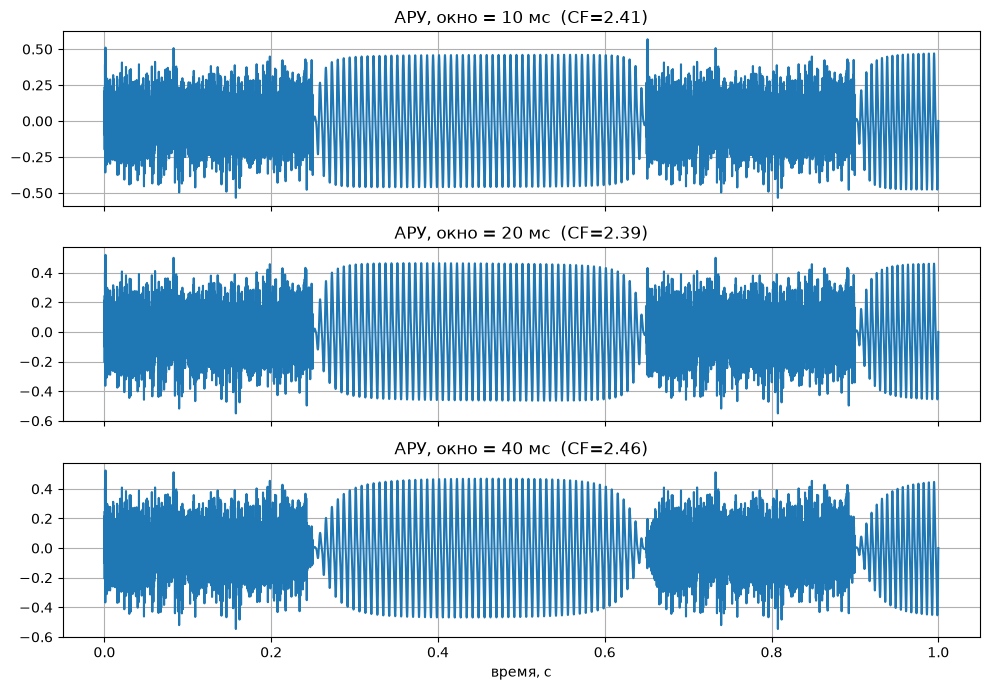

[график сохранён: figures/task3_5_window_comparison.png]


In [25]:
# Сравнение окон: вдвое короче и вдвое длиннее
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, w_ms in zip(axes, [win_ms/2, win_ms, win_ms*2]):
    y_w, v_w, g_w = dyn_process(x_speech, fs, win_ms=w_ms, mode="agc", level=level)
    ax.plot(t_speech[mask], y_w[mask])
    ax.set_title(f"АРУ, окно = {w_ms:.0f} мс  (CF={crest(y_w):.2f})")
axes[-1].set_xlabel("время, c")
fig.tight_layout()
save_and_show(fig, "task3_5_window_comparison")

**Влияние длины окна.** Короткое окно (10 мс) отслеживает
огибающую быстрее — АРУ успевает реагировать даже внутри одного периода
основного тона, из-за чего сигнал начинает «дышать»/пульсировать и
слышны искажения формы волны. Длинное окно (40 мс) даёт более плавную,
инерционную огибающую — переходы между тихими и громкими словами
обрабатываются мягче, но реакция на резкие изменения громкости
запаздывает.

**Эффект в паузах (ловушка АРУ).** На стыках между "словами" (тихие
паузы, заполненные слабым шумом) АРУ, стремясь довести уровень до
целевого `level`, сильно **усиливает тишину** — в паузах на графике
`y(n)` виден заметно поднятый уровень шума по сравнению с исходным
сигналом `x(n)`. Это именно тот эффект, о котором предупреждает разд.
1.13: базовая АРУ без порога срабатывания (gate) и инерции атаки/
восстановления "вытаскивает" наверх шум микрофона и фон помещения между
словами.

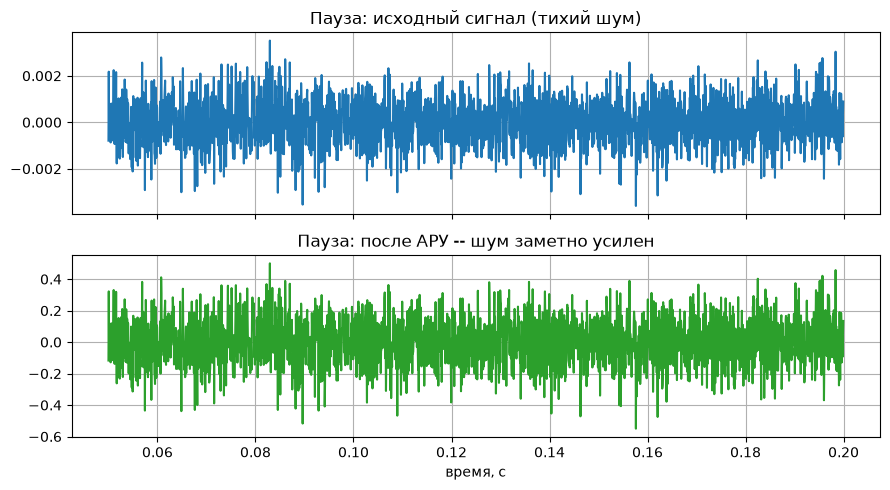

[график сохранён: figures/task3_5_agc_pause_noise.png]
RMS шума в паузе: до АРУ = 0.00099, после АРУ = 0.14933


In [26]:
# Иллюстрация усиления тишины в паузе
pause_start = int(0.05 * fs)
pause_end = int(0.20 * fs)
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t_speech[pause_start:pause_end], x_speech[pause_start:pause_end])
axes[0].set_title("Пауза: исходный сигнал (тихий шум)")
axes[1].plot(t_speech[pause_start:pause_end], y[pause_start:pause_end], color="C2")
axes[1].set_title("Пауза: после АРУ -- шум заметно усилен")
axes[1].set_xlabel("время, c")
fig.tight_layout()
save_and_show(fig, "task3_5_agc_pause_noise")

print(f"RMS шума в паузе: до АРУ = {rms_val(x_speech[pause_start:pause_end]):.5f}, "
      f"после АРУ = {rms_val(y[pause_start:pause_end]):.5f}")

---
# Заключение

В работе реализованы и проверены все основные энергетические
характеристики дискретных сигналов (энергия, мощность, СКЗ, СКО,
пик-фактор), корреляционный анализ (ковариация, коэффициент
корреляции, взаимная и автокорреляционная функции, смещённая и
несмещённая оценки), кратковременный анализ речевого сигнала и базовый
блок динамической обработки (лимитер/АРУ) — согласно варианту 5.
Все построенные графики продублированы в файлах PNG в папке
`figures/` рядом с этим notebook'ом.